In [6]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Third-party imports
from napari import viewer
from skimage import filters
from skimage.morphology import disk, rectangle, closing, opening, erosion, dilation, footprint_rectangle
from skimage.measure import label
from skimage.segmentation import watershed
from skimage.transform import rescale, resize
from scipy import ndimage as ndi
from scipy.ndimage import binary_fill_holes

# Add the src folder to sys.path so it can be imported from the notebook
import sys
import os
src_path = '/Users/taskina/Lab/analysis/img_segmentation/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from utils import load_czi_file
from image_processing import create_binary_mask, watershed_segmentation
from circularity import circ_filter

from circle_fitting import (
    complete_paired_analysis_fast,
    batch_process_files,
    export_batch_results_to_csv,
    print_batch_summary
)

# Optional: Use optimized versions for faster processing
# from scripts.circle_fitting_optimized import complete_paired_analysis_fast, batch_process_files

In [7]:
def process_image(path, ch=0, visualise=False):

    gaus_size=4
    closing_size=2
    ws_size=40

    I = load_czi_file(path, channel=ch)
    #view.add_image(I)
    I_filtered = filters.gaussian(I, sigma=gaus_size)
   #view.add_image(I_filtered)
    I_bin, tr = create_binary_mask(I_filtered, method='threshold_otsu')
    #view.add_image(I_bin)

    I_closed = ~closing(~I_bin, disk(closing_size))
    #view.add_image(I_closed)
    labels = label(I_closed, connectivity=1)
    #view.add_labels(labels)
    #labels_ws = watershed_segmentation(labels, disk_size=ws_size, min_distance=12)
    #view.add_labels(labels_ws)
    lbls_filtered = circ_filter(labels, circularity_filter='manual', circularity_threshold=0.5, size_filter='yen')[0]
    #view.add_labels(lbls_filtered)
    #circles, metrics = circle_fitting(lbls_filtered, image=I, method='contour')

    if visualise:
        # Interactive Napari Viewer
        view = viewer.Viewer()
        view.add_image(I, name='Original')
        view.add_image(I_corrected, name='Corrected')
        view.add_image(I_filtered, name='Filtered')
        view.add_image(I_bin, name='Binary')
        view.add_image(I_closed, name='Closed')
        view.add_labels(labels, name='Labels')
        view.add_labels(lbls_filtered, name='Filtered')

    return lbls_filtered

In [8]:
def process_image_wod_optimized(path, ch=0, visualise=False):
    """Optimized version - 5-10x faster"""
    
    I = load_czi_file(path, channel=ch)
    
    # Fast background correction (downsample method)
    I_small = rescale(I, 0.25, anti_aliasing=False)
    bg_small = filters.gaussian(I_small, sigma=12.5)  # 50/4
    background = resize(bg_small, I.shape, order=1)
    I_corrected = I / background * np.mean(background)
    
    # Light gaussian instead of median (faster, smoother)
    I_filtered = filters.gaussian(I_corrected, sigma=20)
    
    # Binary + morphology with footprint_rectangle (replaces deprecated square)
    I_bin, tr = create_binary_mask(I_filtered, method='threshold_otsu')
    I_dilated = dilation(I_bin, footprint_rectangle([10,10]))
    #I_closed = closing(I_bin, footprint_rectangle([18,18]))

    #I_filled = binary_fill_holes(I_closed)
    
    # Standard processing
    labels = label(I_dilated, connectivity=1)
    labels_ws = watershed_segmentation(labels, disk_size=4, min_distance=20)

    lbls_filtered = circ_filter(labels_ws, circularity_threshold=0.77, circularity_filter='manual', size_filter='yen')[0]
    
    # Fast circle fitting
    #circles, metrics = circle_fitting(lbls_filtered, image=I, method='contour', visualize=True)

    if visualise:
        # Interactive Napari Viewer
        view = viewer.Viewer()
        view.add_image(I, name='Original')
        view.add_image(I_corrected, name='Corrected')
        view.add_image(I_filtered, name='Filtered')
        view.add_image(I_bin, name='Binary')
        view.add_image(I_dilated, name='Dilated')
        #view.add_image(I_closed, name='Closed')
        #view.add_image(I_opened, name='Opened')
        #view.add_image(I_filled, name='Filled')
        view.add_labels(labels, name='Labels')
        view.add_labels(labels_ws, name='Watershed')
        view.add_labels(lbls_filtered, name='Filtered_labels')

    return lbls_filtered

In [11]:
folder_path = '/Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/1uL_RNA'
czi_files = glob.glob(os.path.join(folder_path, '*.czi'))
pixel_size = {'x_um': 0.1952, 'y_um': 0.1952}
results_list_1uL = batch_process_files(
    czi_files,
    condensate_func=process_image,
    wod_func=process_image_wod_optimized,
    pixel_size=pixel_size,
    show_progress=True  # Show progress bar
    )

Processing files:   0%|          | 0/7 [00:00<?, ?it/s]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/1uL_RNA/Snap-6436.czi...
Fitting circles to condensates using 'contour' method...
  Found 3 condensates

Fitting circles to WODs using 'contour' method...
  Found 129 WODs

Pairing condensates with WODs...
  Found 3 pairs


/Users/taskina/Lab/analysis/img_segmentation/src/circle_fitting.py:148: UserWarning: Method 'contour' failed: No module named 'scripts'
  warnings.warn(f"Method '{method}' failed: {e}")
Processing files:  14%|█▍        | 1/7 [00:12<01:15, 12.60s/it]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/1uL_RNA/Snap-6435.czi...
Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 131 WODs

Pairing condensates with WODs...
  Found 2 pairs


Processing files:  29%|██▊       | 2/7 [00:26<01:07, 13.42s/it]

...

Fitting circles to condensates using 'contour' method...
  Found 1 condensates

Fitting circles to WODs using 'contour' method...
  Found 1 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/1uL_RNA/Snap-6433.czi...


Processing files:  86%|████████▌ | 6/7 [01:07<00:10, 10.30s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 10 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/1uL_RNA/Snap-6432.czi...


Processing files: 100%|██████████| 7/7 [01:17<00:00, 11.10s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 9 WODs

Pairing condensates with WODs...
  Found 1 pairs


In [12]:
folder_path = '/Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/2uL_RNA'
czi_files = glob.glob(os.path.join(folder_path, '*.czi'))
pixel_size = {'x_um': 0.1952, 'y_um': 0.1952}
results_list_2uL = batch_process_files(
    czi_files,
    condensate_func=process_image,
    wod_func=process_image_wod_optimized,
    pixel_size=pixel_size,
    show_progress=True  # Show progress bar
    )

Processing files:   0%|          | 0/8 [00:00<?, ?it/s]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/2uL_RNA/Snap-6422.czi...


/Users/taskina/Lab/analysis/img_segmentation/src/circle_fitting.py:148: UserWarning: Method 'contour' failed: No module named 'scripts'
  warnings.warn(f"Method '{method}' failed: {e}")
Processing files:  12%|█▎        | 1/8 [00:09<01:04,  9.22s/it]

Fitting circles to condensates using 'contour' method...
  Found 1 condensates

Fitting circles to WODs using 'contour' method...
  Found 10 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/2uL_RNA/Snap-6423.czi...


Processing files:  25%|██▌       | 2/8 [00:18<00:55,  9.30s/it]

...

Fitting circles to condensates using 'contour' method...
  Found 1 condensates

Fitting circles to WODs using 'contour' method...
  Found 25 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/2uL_RNA/Snap-6428.czi...
Fitting circles to condensates using 'contour' method...
  Found 4 condensates

Fitting circles to WODs using 'contour' method...
  Found 17 WODs

Pairing condensates with WODs...
  Found 4 pairs


Processing files:  88%|████████▊ | 7/8 [01:10<00:10, 10.36s/it]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/2uL_RNA/Snap-6429.czi...


Processing files: 100%|██████████| 8/8 [01:20<00:00, 10.03s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 21 WODs

Pairing condensates with WODs...
  Found 2 pairs


In [13]:
folder_path = '/Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/3uL_RNA'
czi_files = glob.glob(os.path.join(folder_path, '*.czi'))
pixel_size = {'x_um': 0.1952, 'y_um': 0.1952}
results_list_3uL = batch_process_files(
    czi_files,
    condensate_func=process_image,
    wod_func=process_image_wod_optimized,
    pixel_size=pixel_size,
    show_progress=True  # Show progress bar
    )

Processing files:   0%|          | 0/13 [00:00<?, ?it/s]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/3uL_RNA/Snap-6409.czi...


Processing files:   8%|▊         | 1/13 [00:09<01:59,  9.97s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 6 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/3uL_RNA/Snap-6421.czi...


Processing files:  15%|█▌        | 2/13 [00:20<01:51, 10.18s/it]

...

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 8 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/3uL_RNA/Snap-6413.czi...


Processing files:  92%|█████████▏| 12/13 [02:01<00:09,  9.93s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 7 WODs

Pairing condensates with WODs...
  Found 1 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/3uL_RNA/Snap-6407.czi...


Processing files: 100%|██████████| 13/13 [02:10<00:00, 10.02s/it]

Fitting circles to condensates using 'contour' method...
  Found 1 condensates

Fitting circles to WODs using 'contour' method...
  Found 5 WODs

Pairing condensates with WODs...
  Found 1 pairs


In [14]:
folder_path = '/Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/4uL_RNA'
czi_files = glob.glob(os.path.join(folder_path, '*.czi'))
pixel_size = {'x_um': 0.1952, 'y_um': 0.1952}
results_list_4uL = batch_process_files(
    czi_files,
    condensate_func=process_image,
    wod_func=process_image_wod_optimized,
    pixel_size=pixel_size,
    show_progress=True  # Show progress bar
    )

Processing files:   0%|          | 0/8 [00:00<?, ?it/s]

Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/4uL_RNA/Snap-6403.czi...


Processing files:  12%|█▎        | 1/8 [00:10<01:13, 10.46s/it]

Fitting circles to condensates using 'contour' method...
  Found 4 condensates

Fitting circles to WODs using 'contour' method...
  Found 11 WODs

Pairing condensates with WODs...
  Found 3 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/4uL_RNA/Snap-6399.czi...


Processing files:  25%|██▌       | 2/8 [00:20<01:00, 10.10s/it]

...

Fitting circles to condensates using 'contour' method...
  Found 3 condensates

Fitting circles to WODs using 'contour' method...
  Found 14 WODs

Pairing condensates with WODs...
  Found 3 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/4uL_RNA/Snap-6404.czi...


Processing files:  88%|████████▊ | 7/8 [01:10<00:09,  9.99s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 10 WODs

Pairing condensates with WODs...
  Found 2 pairs
Processing /Users/taskina/Lab/raw/confocal/_ARCHIVE_2025/build_phase_diagram/2025-12_08/4uL_RNA/Snap-6406.czi...


Processing files: 100%|██████████| 8/8 [01:20<00:00, 10.02s/it]

Fitting circles to condensates using 'contour' method...
  Found 2 condensates

Fitting circles to WODs using 'contour' method...
  Found 11 WODs

Pairing condensates with WODs...
  Found 2 pairs


# Visualisation section for checking segmentation

In [ ]:
folder_path = '/Users/taskina/Desktop/confocal/8Dec2025/4uL_RNA'
czi_files = glob.glob(os.path.join(folder_path, '*.czi'))
pixel_size = {'x_um': 0.1952, 'y_um': 0.1952}

In [ ]:
i= 0
wod = process_image_wod_optimized(czi_files[i], ch=1, visualise=False)
condensates = process_image(czi_files[i], ch=0)
I = load_czi_file(czi_files[i], channel=1)
I_cond = load_czi_file(czi_files[i], channel=0)

#view.add_image(I, name='WOD')
#view.add_image(I_cond, name='Condensate')
#view.add_labels(condensates)

In [169]:
czi_files[2]

'/Users/taskina/Desktop/confocal/8Dec2025/4uL_RNA/Snap-6399.czi'

In [24]:
pairs, results = complete_paired_analysis_fast(
    condensates, wod,
        pixel_size=pixel_size,
        method='contour',
        is_2d=False
    )

Fitting circles to condensates using 'contour' method...
  Found 4 condensates

Fitting circles to WODs using 'contour' method...
  Found 11 WODs

Pairing condensates with WODs...
  Found 3 pairs


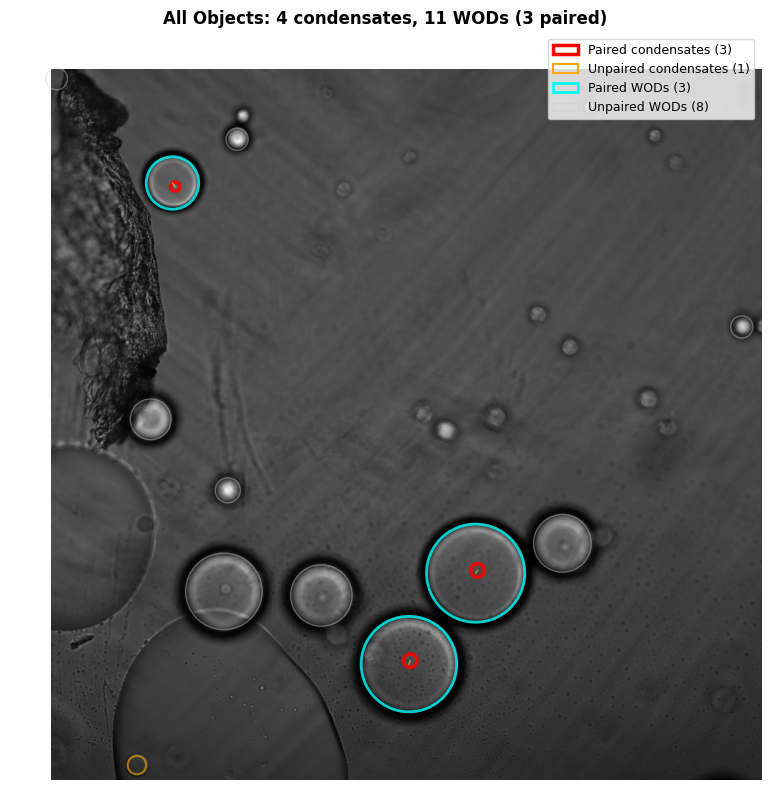


📊 Summary:
  Total condensates: 4
  Paired condensates: 3 (75.0%)
  Unpaired condensates: 1
  Total WODs: 11
  WODs with condensates: 3 (27.3%)
  Empty WODs: 8


In [25]:
# Enhanced overlay view - Show ALL condensates and WODs
from matplotlib.patches import Circle
from scripts.circle_fitting_optimized import fit_circles_robust

# Fit circles to ALL condensates and WODs
all_cond_circles = fit_circles_robust(condensates, methods=['contour', 'area', 'simple'])
all_wod_circles = fit_circles_robust(wod, methods=['contour', 'area', 'simple'])

# Get paired IDs for highlighting
paired_cond_ids = {pair.condensate_id for pair in pairs}
paired_wod_ids = {pair.wod_id for pair in pairs}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(I, cmap='gray')

# Draw ALL WODs (paired in cyan, unpaired in gray)
for cy, cx, r, label_id in all_wod_circles:
    if label_id in paired_wod_ids:
        color = 'cyan'
        alpha = 0.8
        linewidth = 2
    else:
        color = 'lightgray'
        alpha = 0.4
        linewidth = 1
    
    wod_circle = Circle((cx, cy), r, fill=False, edgecolor=color, 
                       linewidth=linewidth, alpha=alpha)
    ax.add_patch(wod_circle)

# Draw ALL condensates (paired in red, unpaired in orange)
for cy, cx, r, label_id in all_cond_circles:
    if label_id in paired_cond_ids:
        color = 'red'
        alpha = 0.9
        linewidth = 2.5
    else:
        color = 'orange'
        alpha = 0.6
        linewidth = 1.5
    
    cond_circle = Circle((cx, cy), r, fill=False, edgecolor=color, 
                        linewidth=linewidth, alpha=alpha)
    ax.add_patch(cond_circle)

# Draw connecting lines for paired condensates
for pair in pairs:
    ax.plot([pair.condensate_center[1], pair.wod_center[1]], 
            [pair.condensate_center[0], pair.wod_center[0]], 
            'yellow', linewidth=1, alpha=0.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor='red', linewidth=2.5, label=f'Paired condensates ({len(pairs)})'),
    Patch(facecolor='none', edgecolor='orange', linewidth=1.5, label=f'Unpaired condensates ({len(all_cond_circles) - len(pairs)})'),
    Patch(facecolor='none', edgecolor='cyan', linewidth=2, label=f'Paired WODs ({len(pairs)})'),
    Patch(facecolor='none', edgecolor='lightgray', linewidth=1, label=f'Unpaired WODs ({len(all_wod_circles) - len(pairs)})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.set_title(f'All Objects: {len(all_cond_circles)} condensates, {len(all_wod_circles)} WODs ({len(pairs)} paired)', 
            fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\n📊 Summary:")
print(f"  Total condensates: {len(all_cond_circles)}")
print(f"  Paired condensates: {len(pairs)} ({len(pairs)/len(all_cond_circles)*100:.1f}%)")
print(f"  Unpaired condensates: {len(all_cond_circles) - len(pairs)}")
print(f"  Total WODs: {len(all_wod_circles)}")
print(f"  WODs with condensates: {len(pairs)} ({len(pairs)/len(all_wod_circles)*100:.1f}%)")
print(f"  Empty WODs: {len(all_wod_circles) - len(pairs)}")

# Continue with analysis

In [15]:
# Aggregate Combined Dataset Analysis
# =====================================
# Collect all volumes from all files

def collect_volumes(results_list, pixel_size):
    all_condensate_volumes = []
    all_wod_volumes = []
    all_volume_ratios = []
    all_wod_radii = []
    all_condensate_radii = []

    for result in results_list:
        if 'pairs' in result and len(result['pairs']) > 0:
            for pair in result['pairs']:
                # Get volumes (physical units if available)
                cond_vol, wod_vol = pair.get_volume_physical(is_2d=False) if pixel_size else pair.get_volume_pixels(is_2d=False)
                all_condensate_volumes.append(cond_vol)
                all_wod_volumes.append(wod_vol)
                all_volume_ratios.append(pair.volume_ratio)
                all_wod_radii.append(pair.wod_radius)
                all_condensate_radii.append(pair.condensate_radius)

    # Convert to numpy arrays for easier manipulation
    all_condensate_volumes = np.array(all_condensate_volumes)
    all_wod_volumes = np.array(all_wod_volumes)
    all_volume_ratios = np.array(all_volume_ratios)
    all_wod_radii = np.array(all_wod_radii)
    all_condensate_radii = np.array(all_condensate_radii)

    '''
    wod_r_tr = 300
    all_condensate_volumes = all_condensate_volumes[all_wod_radii < wod_r_tr] 
    all_wod_volumes = all_wod_volumes[all_wod_radii < wod_r_tr] 
    all_volume_ratios = all_volume_ratios[all_wod_radii < wod_r_tr] 
    all_condensate_radii = all_condensate_radii[all_wod_radii < wod_r_tr] 
    all_wod_radii = all_wod_radii[all_wod_radii < wod_r_tr] 
    '''

    return all_condensate_volumes, all_wod_volumes, all_volume_ratios, all_wod_radii, all_condensate_radii

In [16]:
cond_vol_1uL, wod_vol_1uL, vol_ratio_1uL, wod_radii_1uL, cond_radii_1uL = collect_volumes(results_list_1uL, pixel_size)
cond_vol_2uL, wod_vol_2uL, vol_ratio_2uL, wod_radii_2uL, cond_radii_2uL = collect_volumes(results_list_2uL, pixel_size)
cond_vol_3uL, wod_vol_3uL, vol_ratio_3uL, wod_radii_3uL, cond_radii_3uL = collect_volumes(results_list_3uL, pixel_size)
cond_vol_4uL, wod_vol_4uL, vol_ratio_4uL, wod_radii_4uL, cond_radii_4uL = collect_volumes(results_list_4uL, pixel_size)

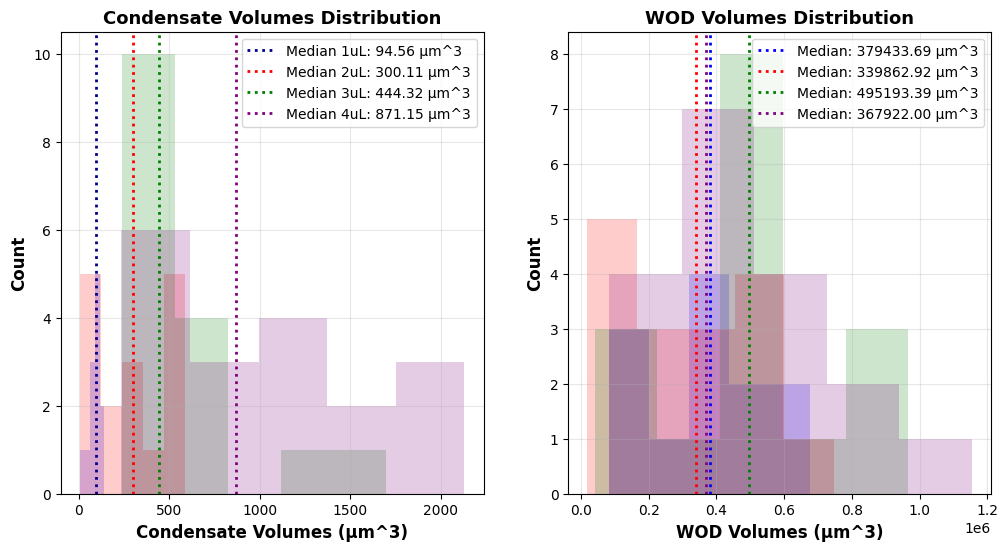

In [17]:
# Create Comprehensive Visualization
# ====================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1. Histogram of Condensate Volumes
ax1 = axes[0]

ax1.hist(cond_vol_1uL, bins=5, color='blue', alpha=0.2)
ax1.axvline(np.median(cond_vol_1uL), color='darkblue', linestyle=':', linewidth=2, label=f'Median 1uL: {np.median(cond_vol_1uL):.2f} µm^3')
ax1.hist(cond_vol_2uL, bins=5, color='red', alpha=0.2)
ax1.axvline(np.median(cond_vol_2uL), color='red', linestyle=':', linewidth=2, label=f'Median 2uL: {np.median(cond_vol_2uL):.2f} µm^3')
ax1.hist(cond_vol_3uL, bins=5, color='green', alpha=0.2)
ax1.axvline(np.median(cond_vol_3uL), color='green', linestyle=':', linewidth=2, label=f'Median 3uL: {np.median(cond_vol_3uL):.2f} µm^3')
ax1.hist(cond_vol_4uL, bins=5, color='purple', alpha=0.2)
ax1.axvline(np.median(cond_vol_4uL), color='purple', linestyle=':', linewidth=2, label=f'Median 4uL: {np.median(cond_vol_4uL):.2f} µm^3')

ax1.set_xlabel('Condensate Volumes (µm^3)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title(f'Condensate Volumes Distribution', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Histogram of WOD Volumes
ax2 = axes[1]

ax2.hist(wod_vol_1uL, bins=5, color='blue', alpha=0.2)
ax2.axvline(np.median(wod_vol_1uL   ), color='blue', linestyle=':', linewidth=2, label=f'Median: {np.median(wod_vol_1uL):.2f} µm^3')
ax2.hist(wod_vol_2uL, bins=5, color='red', alpha=0.2)
ax2.axvline(np.median(wod_vol_2uL), color='red', linestyle=':', linewidth=2, label=f'Median: {np.median(wod_vol_2uL):.2f} µm^3')
ax2.hist(wod_vol_3uL, bins=5, color='green', alpha=0.2)
ax2.axvline(np.median(wod_vol_3uL), color='green', linestyle=':', linewidth=2, label=f'Median: {np.median(wod_vol_3uL):.2f} µm^3')
ax2.hist(wod_vol_4uL, bins=5, color='purple', alpha=0.2)
ax2.axvline(np.median(wod_vol_4uL), color='purple', linestyle=':', linewidth=2, label=f'Median: {np.median(wod_vol_4uL):.2f} µm^3')

ax2.set_xlabel('WOD Volumes (µm^3)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title(f'WOD Volumes Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)


Text(0, 0.5, 'Count')

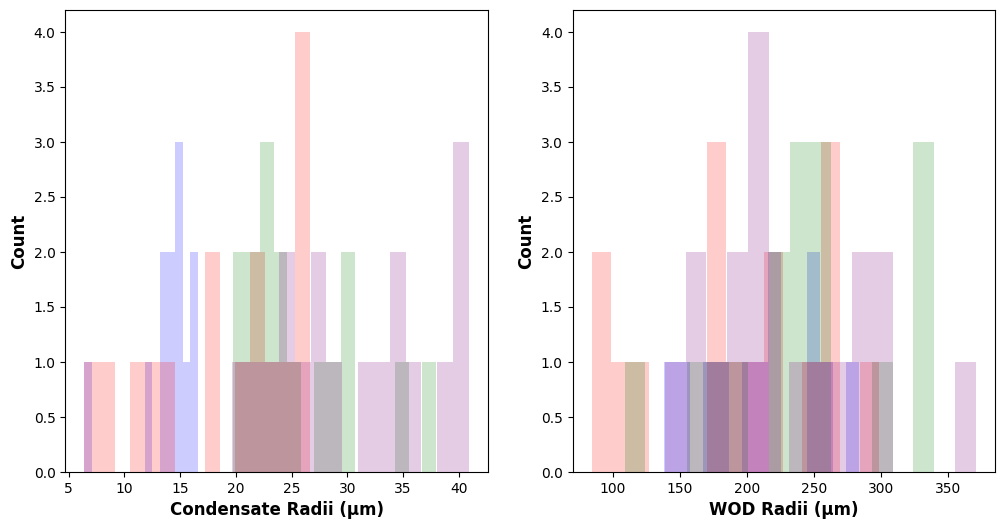

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#3. Histogram of Condensate Radii
ax3 = axes[0]
ax3.hist(cond_radii_1uL, bins=15, color='blue', alpha=0.2)
ax3.hist(cond_radii_2uL, bins=15, color='red', alpha=0.2)
ax3.hist(cond_radii_3uL, bins=15, color='green', alpha=0.2)
ax3.hist(cond_radii_4uL, bins=15, color='purple', alpha=0.2)
ax3.set_xlabel('Condensate Radii (µm)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')

#4. Histogram of WOD Radii
ax4 = axes[1]
ax4.hist(wod_radii_1uL, bins=15, color='blue', alpha=0.2)
ax4.hist(wod_radii_2uL, bins=15, color='red', alpha=0.2)
ax4.hist(wod_radii_3uL, bins=15, color='green', alpha=0.2)
ax4.hist(wod_radii_4uL, bins=15, color='purple', alpha=0.2)
ax4.set_xlabel('WOD Radii (µm)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')

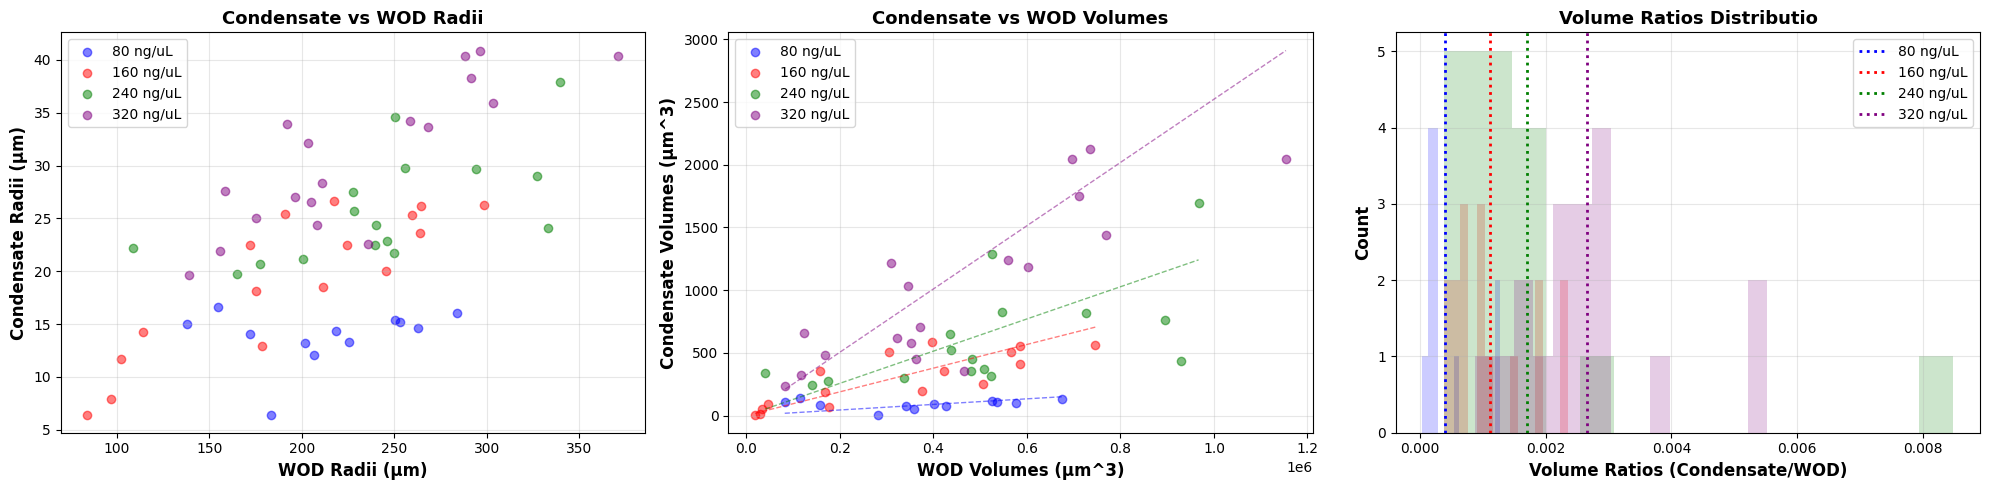

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax1 = axes[0]
ax1.scatter(wod_radii_1uL, cond_radii_1uL, alpha=0.5, color='blue', label='80 ng/uL')
ax1.scatter(wod_radii_2uL, cond_radii_2uL, alpha=0.5, color='red', label='160 ng/uL')
ax1.scatter(wod_radii_3uL, cond_radii_3uL, alpha=0.5, color='green', label='240 ng/uL')
ax1.scatter(wod_radii_4uL, cond_radii_4uL, alpha=0.5, color='purple', label='320 ng/uL')
ax1.legend(fontsize=10)
ax1.set_ylabel('Condensate Radii (µm)', fontsize=12, fontweight='bold')
ax1.set_xlabel('WOD Radii (µm)', fontsize=12, fontweight='bold')
ax1.set_title('Condensate vs WOD Radii', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(wod_vol_1uL, cond_vol_1uL, alpha=0.5, color='blue', label='80 ng/uL')
ax2.scatter(wod_vol_2uL, cond_vol_2uL, alpha=0.5, color='red', label='160 ng/uL')
ax2.scatter(wod_vol_3uL, cond_vol_3uL, alpha=0.5, color='green', label='240 ng/uL')
ax2.scatter(wod_vol_4uL, cond_vol_4uL, alpha=0.5, color='purple', label='320 ng/uL')
ax2.legend(fontsize=10)
ax2.set_ylabel('Condensate Volumes (µm^3)', fontsize=12, fontweight='bold')
ax2.set_xlabel('WOD Volumes (µm^3)', fontsize=12, fontweight='bold')
ax2.set_title('Condensate vs WOD Volumes', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.hist(vol_ratio_1uL, bins=15, color='blue', alpha=0.2)
ax3.axvline(np.mean(vol_ratio_1uL), color='blue', linestyle=':', linewidth=2, label='80 ng/uL')
ax3.hist(vol_ratio_2uL, bins=15, color='red', alpha=0.2)
ax3.axvline(np.mean(vol_ratio_2uL), color='red', linestyle=':', linewidth=2, label='160 ng/uL')
ax3.hist(vol_ratio_3uL, bins=15, color='green', alpha=0.2)
ax3.axvline(np.mean(vol_ratio_3uL), color='green', linestyle=':', linewidth=2, label='240 ng/uL')
ax3.hist(vol_ratio_4uL, bins=15, color='purple', alpha=0.2)
ax3.axvline(np.mean(vol_ratio_4uL), color='purple', linestyle=':', linewidth=2, label='320 ng/uL')
ax3.set_xlabel('Volume Ratios (Condensate/WOD)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Volume Ratios Distributio', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

m_1uL = np.median(vol_ratio_1uL)
mean_1uL = np.mean(vol_ratio_1uL)
m_2uL = np.median(vol_ratio_2uL)
mean_2uL = np.mean(vol_ratio_2uL)
m_3uL = np.median(vol_ratio_3uL)
mean_3uL = np.mean(vol_ratio_3uL)
m_4uL = np.median(vol_ratio_4uL)
mean_4uL = np.mean(vol_ratio_4uL)
ax2.plot([np.min(wod_vol_1uL), np.max(wod_vol_1uL)], [np.min(wod_vol_1uL)*m_1uL, np.max(wod_vol_1uL)*m_1uL], color='blue', linewidth=1, linestyle = '--', alpha=0.5)
ax2.plot([np.min(wod_vol_2uL), np.max(wod_vol_2uL)], [np.min(wod_vol_2uL)*m_2uL, np.max(wod_vol_2uL)*m_2uL], color='red', linewidth=1, linestyle = '--', alpha=0.5)
ax2.plot([np.min(wod_vol_3uL), np.max(wod_vol_3uL)], [np.min(wod_vol_3uL)*m_3uL, np.max(wod_vol_3uL)*m_3uL], color='green', linewidth=1, linestyle = '--', alpha=0.5)
ax2.plot([np.min(wod_vol_4uL), np.max(wod_vol_4uL)], [np.min(wod_vol_4uL)*m_4uL, np.max(wod_vol_4uL)*m_4uL], color='purple', linewidth=1, linestyle = '--', alpha=0.5)

plt.tight_layout()



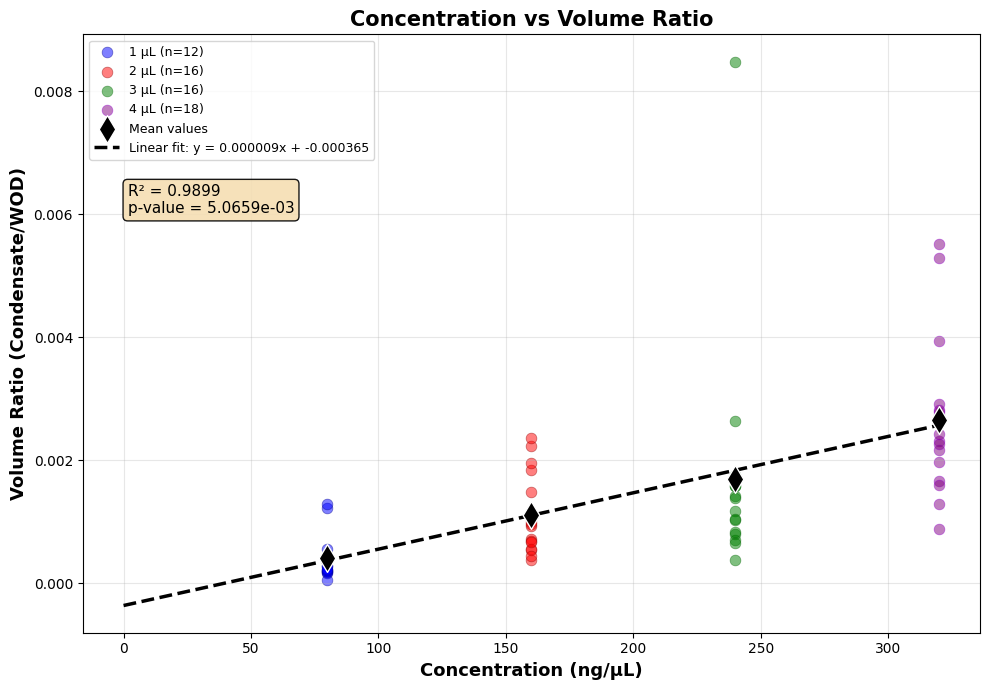


📈 Linear Regression Results (based on mean values):
  Equation: y = 0.00000917x + -0.00036478
  Slope: 0.00000917
  Intercept: -0.00036478
  R² (coefficient of determination): 0.98989380
  Pearson correlation coefficient (r): 0.99493407
  p-value: 5.0659e-03
  Standard error: 6.5501e-07


In [20]:
conc = [(800/10)*1, (800/10)*2, (800/10)*3, (800/10)*4]
m = [mean_1uL, mean_2uL, mean_3uL, mean_4uL]

# Prepare all individual data points
conc_1 = np.full(len(vol_ratio_1uL), conc[0])
conc_2 = np.full(len(vol_ratio_2uL), conc[1])
conc_3 = np.full(len(vol_ratio_3uL), conc[2])
conc_4 = np.full(len(vol_ratio_4uL), conc[3])

# Calculate linear regression based on MEAN values
conc_array = np.array(conc)
m_array = np.array(m)

from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(conc_array, m_array)

# Create regression line
x_fit = np.linspace(0, conc_array.max(), 100)
y_fit = slope * x_fit + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot ALL individual data points (smaller, transparent)
ax.scatter(conc_1, vol_ratio_1uL, s=60, alpha=0.5, color='blue', edgecolor='darkblue', linewidth=0.5, label=f'1 µL (n={len(vol_ratio_1uL)})')
ax.scatter(conc_2, vol_ratio_2uL, s=60, alpha=0.5, color='red', edgecolor='darkred', linewidth=0.5, label=f'2 µL (n={len(vol_ratio_2uL)})')
ax.scatter(conc_3, vol_ratio_3uL, s=60, alpha=0.5, color='green', edgecolor='darkgreen', linewidth=0.5, label=f'3 µL (n={len(vol_ratio_3uL)})')
ax.scatter(conc_4, vol_ratio_4uL, s=60, alpha=0.5, color='purple', edgecolor='darkviolet', linewidth=0.5, label=f'4 µL (n={len(vol_ratio_4uL)})')

# Plot MEAN values (larger, prominent)
ax.scatter(conc, m, s=200, alpha=1.0, color='black', marker='d', edgecolor='white', linewidth=1, 
          label='Mean values', zorder=5)

# Plot linear regression based on means
ax.plot(x_fit, y_fit, 'k--', linewidth=2.5, label=f'Linear fit: y = {slope:.6f}x + {intercept:.6f}', zorder=4)

# Add statistics to plot
textstr = f'R² = {r_value**2:.4f}\np-value = {p_value:.4e}'
ax.text(0.05, 0.75, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

ax.set_xlabel('Concentration (ng/µL)', fontsize=13, fontweight='bold')
ax.set_ylabel('Volume Ratio (Condensate/WOD)', fontsize=13, fontweight='bold')
ax.set_title('Concentration vs Volume Ratio', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Linear Regression Results (based on mean values):")
print(f"=" * 60)
print(f"  Equation: y = {slope:.8f}x + {intercept:.8f}")
print(f"  Slope: {slope:.8f}")
print(f"  Intercept: {intercept:.8f}")
print(f"  R² (coefficient of determination): {r_value**2:.8f}")
print(f"  Pearson correlation coefficient (r): {r_value:.8f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Standard error: {std_err:.4e}")




In [ ]:
# Phase Concentration Calculations with Error Propagation
# According to Equation 1: Vfrac = a·c(tot) + b
# Where: c(cond) = (1-b)/a and c(dil) = -b/a

# Calculate 95% confidence intervals for slope and intercept
from scipy import stats as scipy_stats

# Get fit parameters from previous cell
a = slope  # slope from linear regression
b = intercept  # intercept from linear regression

n = len(conc_array)
t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence, two-tailed

# Standard errors (from regression)
se_slope = std_err
y_pred_calc = slope * conc_array + intercept
residuals_calc = m_array - y_pred_calc
mse = np.sum(residuals_calc**2) / (n - 2)
x_mean = np.mean(conc_array)
sxx = np.sum((conc_array - x_mean)**2)
se_intercept = np.sqrt(mse * (1/n + x_mean**2/sxx))

# 95% confidence intervals for fit parameters
ci_slope = t_val * se_slope
ci_intercept = t_val * se_intercept

print(f"\n" + "="*75)
print(f"  PHASE SEPARATION ANALYSIS (Equation 1)")
print(f"="*75)
print(f"\n📊 Fit Parameters with 95% Confidence Intervals:")
print(f"-" * 75)
print(f"  a (slope):     {a:.8f} ± {ci_slope:.8f}")
print(f"                 [{a - ci_slope:.8f}, {a + ci_slope:.8f}]")
print(f"  b (intercept): {b:.8f} ± {ci_intercept:.8f}")
print(f"                 [{b - ci_intercept:.8f}, {b + ci_intercept:.8f}]")

# Calculate phase concentrations
# c(cond) = (1-b)/a (condensed phase concentration)
# c(dil) = -b/a      (dilute phase concentration)

c_cond = (1 - b) / a
c_dil = -b / a

# Error propagation for c(cond) = (1-b)/a
# Partial derivatives:
# ∂c_cond/∂b = -1/a
# ∂c_cond/∂a = -(1-b)/a²
dc_cond_da = -(1-b) / (a**2)
dc_cond_db =  -1/a 
sigma_c_cond = np.sqrt((dc_cond_da * se_slope)**2 + (dc_cond_db * se_intercept)**2)
ci_c_cond = t_val * sigma_c_cond

# Error propagation for c(dil) = -b/a
# Partial derivatives:
# ∂c_dil/∂a = b/a²
# ∂c_dil/∂b = -1/a
dc_dil_da = b / (a**2)
dc_dil_db = -1 / a
sigma_c_dil = np.sqrt((dc_dil_da * se_slope)**2 + (dc_dil_db * se_intercept)**2)
ci_c_dil = t_val * sigma_c_dil

print(f"\n🔬 Phase Concentrations:")
print(f"-" * 75)
print(f"  Condensed Phase: c(cond) = (1-b)/a")
print(f"    c(cond) = {c_cond:.4f} ± {ci_c_cond:.4f} ng/µL")
print(f"    95% CI: [{c_cond - ci_c_cond:.4f}, {c_cond + ci_c_cond:.4f}] ng/µL")
print(f"")
print(f"  Dilute Phase: c(dil) = -b/a")
print(f"    c(dil) = {c_dil:.4f} ± {ci_c_dil:.4f} ng/µL")
print(f"    95% CI: [{c_dil - ci_c_dil:.4f}, {c_dil + ci_c_dil:.4f}] ng/µL")
print(f"")
print(f"  Enrichment Factor: c(cond)/c(dil) = {c_cond/c_dil:.2f}×")
print(f"")
print(f"📝 Note: Uncertainties calculated via error propagation:")
print(f"   σ = √[(∂f/∂a)²·σ_a² + (∂f/∂b)²·σ_b²]")
print(f"   95% CI from t-distribution (df={n-2}, α=0.05)")
print(f"="*75)



  PHASE SEPARATION ANALYSIS (Equation 1)

📊 Fit Parameters with 95% Confidence Intervals:
---------------------------------------------------------------------------
  a (slope):     0.00000917 ± 0.00000282
                 [0.00000635, 0.00001199]
  b (intercept): -0.00036478 ± 0.00061745
                 [-0.00098223, 0.00025268]

🔬 Phase Concentrations:
---------------------------------------------------------------------------
  Condensed Phase: c(cond) = (1-b)/a
    c(cond) = 109117.6500 ± 33544.1534 ng/µL
    95% CI: [75573.4966, 142661.8034] ng/µL

  Dilute Phase: c(dil) = -b/a
    c(dil) = 39.7891 ± 68.4523 ng/µL
    95% CI: [-28.6632, 108.2414] ng/µL

  Enrichment Factor: c(cond)/c(dil) = 2742.40×

📝 Note: Uncertainties calculated via error propagation:
   σ = √[(∂f/∂a)²·σ_a² + (∂f/∂b)²·σ_b²]
   95% CI from t-distribution (df=2, α=0.05)


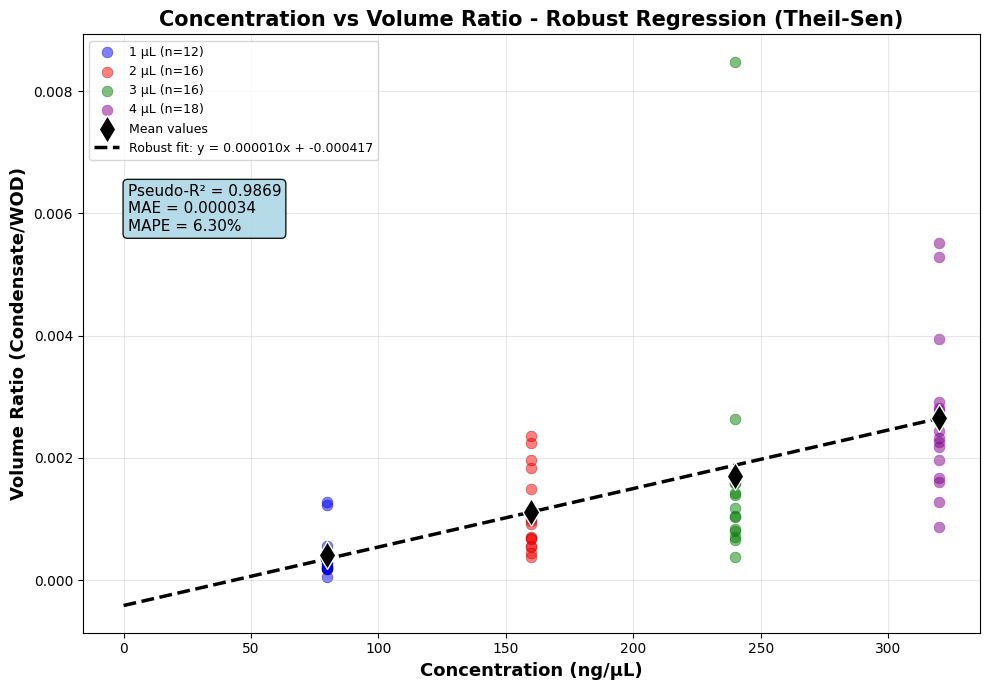


📈 Robust Regression Results (Theil-Sen Estimator):
  Method: Theil-Sen (median-based, robust to outliers)
  Equation: y = 0.00000957x + -0.00041750
  Slope: 0.00000957
  Intercept: -0.00041750
  Pseudo-R² (robust goodness-of-fit): 0.98691922
  Median Absolute Error (MAE): 0.00003385
  Mean Absolute Percentage Error (MAPE): 6.30%


In [26]:
# ROBUST REGRESSION VERSION - Replace Cell 18 with this
conc = [(800/10)*1, (800/10)*2, (800/10)*3, (800/10)*4]
m = [mean_1uL, mean_2uL, mean_3uL, mean_4uL]

# Prepare all individual data points
conc_1 = np.full(len(vol_ratio_1uL), conc[0])
conc_2 = np.full(len(vol_ratio_2uL), conc[1])
conc_3 = np.full(len(vol_ratio_3uL), conc[2])
conc_4 = np.full(len(vol_ratio_4uL), conc[3])

# ROBUST regression using Theil-Sen estimator (robust to outliers)
from sklearn.linear_model import TheilSenRegressor
from sklearn.metrics import median_absolute_error

conc_array = np.array(conc).reshape(-1, 1)
m_array = np.array(m)

# Fit Theil-Sen robust regression
robust_reg = TheilSenRegressor(random_state=42)
robust_reg.fit(conc_array, m_array)

slope = robust_reg.coef_[0]
intercept = robust_reg.intercept_

# Predictions and robust metrics
y_pred = robust_reg.predict(conc_array)

# Pseudo-R² (uses median, not mean - more robust)
ss_res = np.sum((m_array - y_pred) ** 2)
ss_tot = np.sum((m_array - np.median(m_array)) ** 2)
pseudo_r2 = 1 - (ss_res / ss_tot)

# Median Absolute Error
mae = median_absolute_error(m_array, y_pred)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((m_array - y_pred) / m_array)) * 100

# Regression line
x_fit = np.linspace(0, conc_array.max(), 100)
y_fit = slope * x_fit + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Individual data points
ax.scatter(conc_1, vol_ratio_1uL, s=60, alpha=0.5, color='blue', edgecolor='darkblue', linewidth=0.5, label=f'1 µL (n={len(vol_ratio_1uL)})')
ax.scatter(conc_2, vol_ratio_2uL, s=60, alpha=0.5, color='red', edgecolor='darkred', linewidth=0.5, label=f'2 µL (n={len(vol_ratio_2uL)})')
ax.scatter(conc_3, vol_ratio_3uL, s=60, alpha=0.5, color='green', edgecolor='darkgreen', linewidth=0.5, label=f'3 µL (n={len(vol_ratio_3uL)})')
ax.scatter(conc_4, vol_ratio_4uL, s=60, alpha=0.5, color='purple', edgecolor='darkviolet', linewidth=0.5, label=f'4 µL (n={len(vol_ratio_4uL)})')

# Mean values
ax.scatter(conc, m, s=200, alpha=1.0, color='black', marker='d', edgecolor='white', linewidth=1, 
          label='Mean values', zorder=5)

# Robust regression line
ax.plot(x_fit, y_fit, 'k--', linewidth=2.5, label=f'Robust fit: y = {slope:.6f}x + {intercept:.6f}', zorder=4)

# Statistics box
textstr = f'Pseudo-R² = {pseudo_r2:.4f}\nMAE = {mae:.6f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.75, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))

ax.set_xlabel('Concentration (ng/µL)', fontsize=13, fontweight='bold')
ax.set_ylabel('Volume Ratio (Condensate/WOD)', fontsize=13, fontweight='bold')
ax.set_title('Concentration vs Volume Ratio - Robust Regression (Theil-Sen)', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Robust Regression Results (Theil-Sen Estimator):")
print(f"=" * 70)
print(f"  Method: Theil-Sen (median-based, robust to outliers)")
print(f"  Equation: y = {slope:.8f}x + {intercept:.8f}")
print(f"  Slope: {slope:.8f}")
print(f"  Intercept: {intercept:.8f}")
print(f"  Pseudo-R² (robust goodness-of-fit): {pseudo_r2:.8f}")
print(f"  Median Absolute Error (MAE): {mae:.8f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


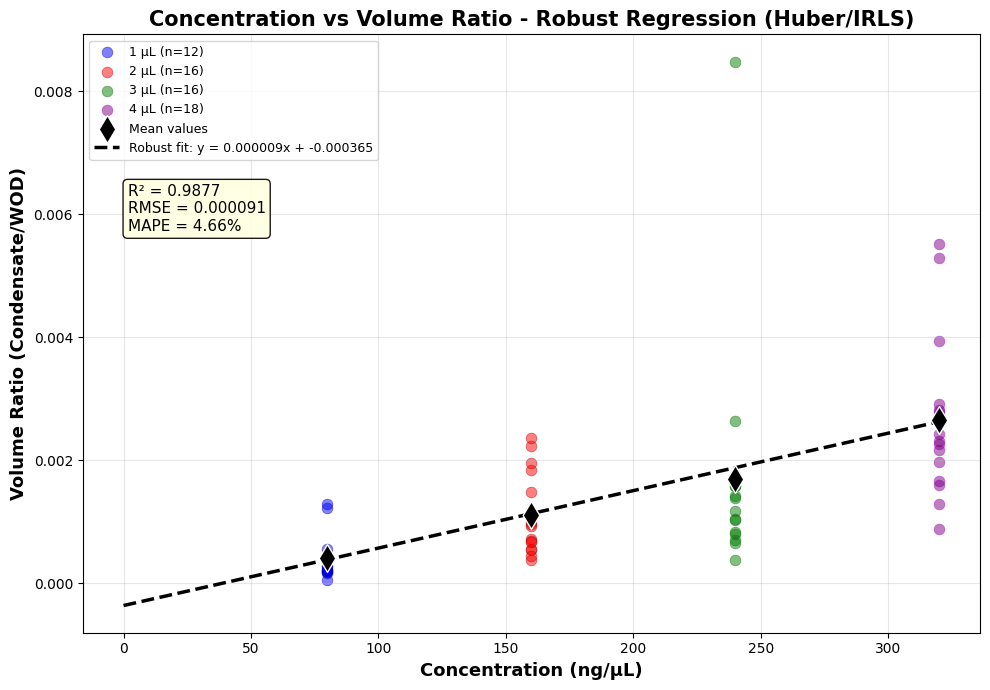


📈 Robust Regression Results (Huber Regression - MATLAB robustfit equivalent):
  Method: Huber Regression (IRLS with Huber weights)
  Similar to: MATLAB's robustfit(X, y)
  Equation: y = 0.00000934x + -0.00036479
  Slope: 0.00000934
  Intercept: -0.00036479
  R² (coefficient of determination): 0.98770695
  RMSE (Root Mean Squared Error): 0.00009138
  MAE (Mean Absolute Error): 0.00006166
  MAPE (Mean Absolute Percentage Error): 4.66%

ℹ️  Huber regression uses IRLS to downweight outliers.
    This is the closest Python equivalent to MATLAB's robustfit().


In [27]:
# MATLAB robustfit() EQUIVALENT - Uses IRLS with Huber weights
conc = [(800/10)*1, (800/10)*2, (800/10)*3, (800/10)*4]
m = [mean_1uL, mean_2uL, mean_3uL, mean_4uL]

# Prepare all individual data points
conc_1 = np.full(len(vol_ratio_1uL), conc[0])
conc_2 = np.full(len(vol_ratio_2uL), conc[1])
conc_3 = np.full(len(vol_ratio_3uL), conc[2])
conc_4 = np.full(len(vol_ratio_4uL), conc[3])

# MATLAB robustfit equivalent: HuberRegressor (IRLS with Huber weights)
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score, mean_absolute_error

conc_array = np.array(conc).reshape(-1, 1)
m_array = np.array(m)

# Fit Huber regression (similar to MATLAB's robustfit)
huber_reg = HuberRegressor(epsilon=1.35, max_iter=100)  # epsilon=1.35 is standard for Huber
huber_reg.fit(conc_array, m_array)

slope = huber_reg.coef_[0]
intercept = huber_reg.intercept_

# Predictions and metrics
y_pred = huber_reg.predict(conc_array)

# R² (can use standard R² for Huber)
r2 = r2_score(m_array, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(m_array, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(np.mean((m_array - y_pred) ** 2))

# Mean Absolute Percentage Error
mape = np.mean(np.abs((m_array - y_pred) / m_array)) * 100

# Regression line
x_fit = np.linspace(0, conc_array.max(), 100)
y_fit = slope * x_fit + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Individual data points
ax.scatter(conc_1, vol_ratio_1uL, s=60, alpha=0.5, color='blue', edgecolor='darkblue', linewidth=0.5, label=f'1 µL (n={len(vol_ratio_1uL)})')
ax.scatter(conc_2, vol_ratio_2uL, s=60, alpha=0.5, color='red', edgecolor='darkred', linewidth=0.5, label=f'2 µL (n={len(vol_ratio_2uL)})')
ax.scatter(conc_3, vol_ratio_3uL, s=60, alpha=0.5, color='green', edgecolor='darkgreen', linewidth=0.5, label=f'3 µL (n={len(vol_ratio_3uL)})')
ax.scatter(conc_4, vol_ratio_4uL, s=60, alpha=0.5, color='purple', edgecolor='darkviolet', linewidth=0.5, label=f'4 µL (n={len(vol_ratio_4uL)})')

# Mean values
ax.scatter(conc, m, s=200, alpha=1.0, color='black', marker='d', edgecolor='white', linewidth=1, 
          label='Mean values', zorder=5)

# Robust regression line
ax.plot(x_fit, y_fit, 'k--', linewidth=2.5, label=f'Robust fit: y = {slope:.6f}x + {intercept:.6f}', zorder=4)

# Statistics box
textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.6f}\nMAPE = {mape:.2f}%'
ax.text(0.05, 0.75, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('Concentration (ng/µL)', fontsize=13, fontweight='bold')
ax.set_ylabel('Volume Ratio (Condensate/WOD)', fontsize=13, fontweight='bold')
ax.set_title('Concentration vs Volume Ratio - Robust Regression (Huber/IRLS)', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Robust Regression Results (Huber Regression - MATLAB robustfit equivalent):")
print(f"=" * 75)
print(f"  Method: Huber Regression (IRLS with Huber weights)")
print(f"  Similar to: MATLAB's robustfit(X, y)")
print(f"  Equation: y = {slope:.8f}x + {intercept:.8f}")
print(f"  Slope: {slope:.8f}")
print(f"  Intercept: {intercept:.8f}")
print(f"  R² (coefficient of determination): {r2:.8f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:.8f}")
print(f"  MAE (Mean Absolute Error): {mae:.8f}")
print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"\nℹ️  Huber regression uses IRLS to downweight outliers.")
print(f"    This is the closest Python equivalent to MATLAB's robustfit().")
